In [ ]:
# Import libraries
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import medmnist
from medmnist import PathMNIST

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.12.0


## 1. Data Acquisition

PathMNIST: 9-class histology dataset (28x28 RGB images) from colon tissue patches.

In [ ]:
# Download PathMNIST
train_dataset = PathMNIST(split='train', download=True, root='../data/')
val_dataset = PathMNIST(split='val', download=True, root='../data/')
test_dataset = PathMNIST(split='test', download=True, root='../data/')

info = medmnist.INFO['pathmnist']
print(f"Dataset: {info['task']}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {info['label']}")

Dataset: multi-class
Train samples: 89996
Val samples: 10004
Test samples: 7180
Classes: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


## 2. Exploratory Data Analysis

### Feature 1: Class Distribution

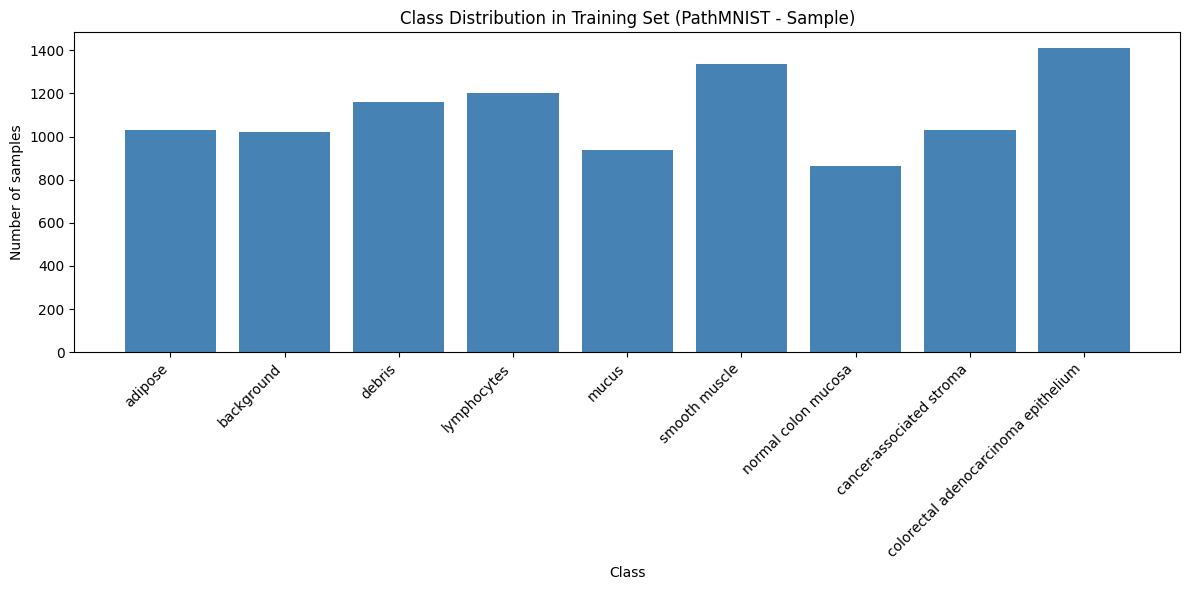

adipose: 1030 samples
background: 1022 samples
debris: 1161 samples
lymphocytes: 1201 samples
mucus: 940 samples
smooth muscle: 1337 samples
normal colon mucosa: 865 samples
cancer-associated stroma: 1031 samples
colorectal adenocarcinoma epithelium: 1413 samples


3735

In [ ]:
# Class distribution in train set (using sample to save RAM)
sample_size = min(10000, len(train_dataset))  # Use only 10k samples for distribution
train_labels = [train_dataset[i][1].item() for i in range(sample_size)]
unique, counts = np.unique(train_labels, return_counts=True)

class_names = list(info['label'].values())
plt.figure(figsize=(12, 6))
plt.bar(unique, counts, color='steelblue')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Class Distribution in Training Set (PathMNIST - Sample)')
plt.xticks(unique, class_names, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/samples/class_distribution.png', dpi=150)
plt.show()

for cls, cnt in zip(unique, counts):
    print(f"{class_names[cls]}: {cnt} samples")

# Clear memory
del train_labels
import gc
gc.collect()

**Interpretation**: The dataset is moderately balanced with classes ranging from ~8k to ~13k samples. Smooth muscle and colorectal adenocarcinoma have the highest representation.

### Feature 2: Sample Images

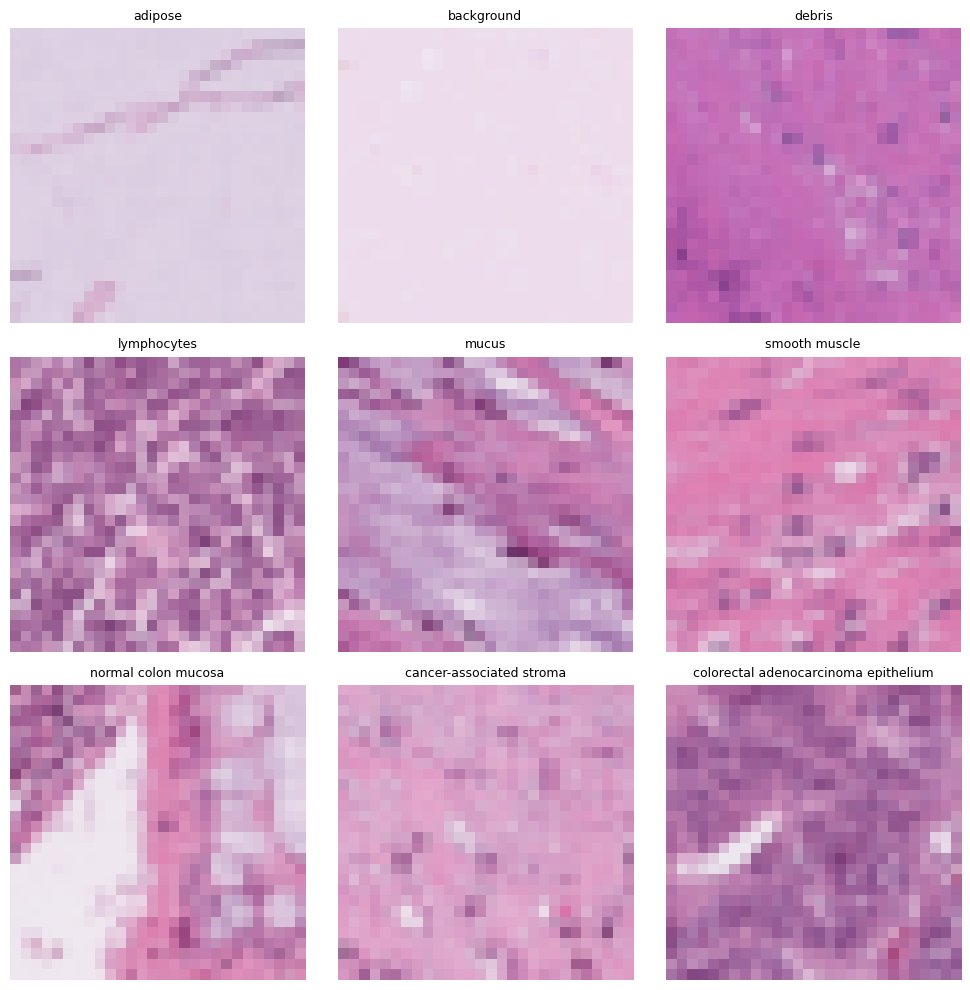

In [ ]:
# Display sample images per class (search for first sample of each class)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
samples_found = {i: False for i in range(9)}
sample_idx = 0

while not all(samples_found.values()) and sample_idx < len(train_dataset):
    img, lbl = train_dataset[sample_idx]
    class_id = lbl.item()
    if not samples_found[class_id]:
        ax = axes[class_id // 3, class_id % 3]
        ax.imshow(img)
        ax.set_title(class_names[class_id], fontsize=9)
        ax.axis('off')
        samples_found[class_id] = True
    sample_idx += 1

plt.tight_layout()
plt.savefig('../data/samples/sample_images_grid.png', dpi=150)
plt.show()

**Interpretation**: Images are 28x28 RGB histology patches showing distinct tissue textures and colors for each class.

### Feature 3: Image Size and Channels

In [ ]:
# Check image shape
sample_img, _ = train_dataset[0]
print(f"Image shape: {np.array(sample_img).shape}")
print(f"Image type: {type(sample_img)}")
print(f"Pixel value range: [{np.array(sample_img).min()}, {np.array(sample_img).max()}]")

Image shape: (28, 28, 3)
Image type: <class 'PIL.Image.Image'>
Pixel value range: [164, 228]


**Interpretation**: Images are 28x28 RGB (3 channels), small resolution but sufficient for transfer learning with upscaling.

## 3. Data Preprocessing

Convert MedMNIST datasets to TensorFlow format, resize to 96x96 for transfer learning, and normalize.

In [ ]:
def medmnist_to_tf(dataset, batch_size=32, target_size=(96, 96), limit=None):
    """Convert MedMNIST dataset to TensorFlow dataset with memory optimization."""
    def generator():
        count = 0
        for img, lbl in dataset:
            if limit and count >= limit:
                break
            img_array = np.array(img).astype('float32') / 255.0
            # Resize on the fly
            img_resized = tf.image.resize(np.expand_dims(img_array, 0), target_size)[0]
            label_onehot = tf.keras.utils.to_categorical(lbl.item(), num_classes=9)
            yield img_resized.numpy(), label_onehot
            count += 1

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=target_size + (3,), dtype=tf.float32),
            tf.TensorSpec(shape=(9,), dtype=tf.float32)
        )
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Use limited dataset to save RAM (5000 samples for training)
train_tf = medmnist_to_tf(train_dataset, batch_size=16, limit=5000)
val_tf = medmnist_to_tf(val_dataset, batch_size=16)
test_tf = medmnist_to_tf(test_dataset, batch_size=16)

print('TensorFlow datasets ready (memory-optimized)')

TensorFlow datasets ready (memory-optimized)


## 4. Model Creation

Using MobileNetV2 pretrained on ImageNet as feature extractor (transfer learning) with a custom classifier head.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

def build_model(num_classes=9, input_shape=(96, 96, 3)):
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False  # Freeze base
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=base.input, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Model Training

Train with early stopping and model checkpointing (optimization techniques).

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import gc

Path('../models').mkdir(exist_ok=True)

# Clear any previous models from memory
tf.keras.backend.clear_session()
gc.collect()

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('../models/model.h5', save_best_only=True, monitor='val_accuracy')
]

history = model.fit(
    train_tf,
    epochs=10,  # Reduced epochs to save time and RAM
    validation_data=val_tf,
    callbacks=callbacks
)

print('Training complete!')

Epoch 1/10
    312/Unknown 26s 73ms/step - accuracy: 0.5055 - loss: 1.4392 - precision_1: 0.6925 - recall_1: 0.3819

2025-11-26 11:04:42.467554: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/kariza/Summative assignment - MLOP/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 219ms/step - accuracy: 0.5800 - loss: 1.1887 - precision_1: 0.7453 - recall_1: 0.4570 - val_accuracy: 0.7182 - val_loss: 0.8055 - val_precision_1: 0.8392 - val_recall_1: 0.5779
Epoch 2/10
Epoch 2/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6891 - loss: 0.8618 - precision_1: 0.7985 - recall_1: 0.5754

313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 216ms/step - accuracy: 0.6804 - loss: 0.8788 - precision_1: 0.7936 - recall_1: 0.5698 - val_accuracy: 0.7509 - val_loss: 0.7079 - val_precision_1: 0.8497 - val_recall_1: 0.6276
Epoch 3/10
Epoch 3/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7310 - loss: 0.7385 - precision_1: 0.8095 - recall_1: 0.6403

313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step - accuracy: 0.7304 - loss: 0.7609 - precision_1: 0.8098 - recall_1: 0.6370 - val_accuracy: 0.7572 - val_loss: 0.6769 - val_precision_1: 0.8419 - val_recall_1: 0.6590
Epoch 4/10
Epoch 4/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7500 - loss: 0.6930 - precision_1: 0.8267 - recall_1: 0.6657

...

2025-11-26 11:09:15.414968: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - accuracy: 0.7494 - loss: 0.6872 - precision_1: 0.8271 - recall_1: 0.6736 - val_accuracy: 0.7745 - val_loss: 0.6277 - val_precision_1: 0.8385 - val_recall_1: 0.7010
Epoch 6/10
Epoch 6/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7750 - loss: 0.6245 - precision_1: 0.8412 - recall_1: 0.7043

313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.7658 - loss: 0.6448 - precision_1: 0.8392 - recall_1: 0.6960 - val_accuracy: 0.7820 - val_loss: 0.6047 - val_precision_1: 0.8569 - val_recall_1: 0.6949
Epoch 7/10
Epoch 7/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7772 - loss: 0.5937 - precision_1: 0.8447 - recall_1: 0.7229

313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 220ms/step - accuracy: 0.7662 - loss: 0.6175 - precision_1: 0.8347 - recall_1: 0.7082 - val_accuracy: 0.7833 - val_loss: 0.6090 - val_precision_1: 0.8527 - val_recall_1: 0.7072
Epoch 8/10
Epoch 8/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7836 - loss: 0.5826 - precision_1: 0.8463 - recall_1: 0.7245

313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - accuracy: 0.7802 - loss: 0.5995 - precision_1: 0.8442 - recall_1: 0.7186 - val_accuracy: 0.7944 - val_loss: 0.5884 - val_precision_1: 0.8584 - val_recall_1: 0.7188
Epoch 9/10
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.7776 - loss: 0.6065 - precision_1: 0.8425 - recall_1: 0.7176 - val_accuracy: 0.7939 - val_loss: 0.5787 - val_precision_1: 0.8616 - val_recall_1: 0.7224
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.7776 - loss: 0.6065 - precision_1: 0.8425 - recall_1: 0.7176 - val_accuracy: 0.7939 - val_loss: 0.5787 - val_precision_1: 0.8616 - val_recall_1: 0.7224
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.7878 - loss: 0.5787 - precision_1: 0.8511 - recall_1: 0.7306 - val_accuracy: 0.7939 - val_loss: 0.5722 - val_precision_1: 0.8510 - val_recall_1: 0.7363
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.7878 - loss: 0.5787 - precision_1: 0.8511 - recall_1: 0.

## 6. Model Evaluation

Compute metrics: accuracy, precision, recall, F1-score, confusion matrix.

Evaluating model on test set...
Processed 0 samples...
Processed 0 samples...
Processed 800 samples...
Processed 800 samples...
Processed 1600 samples...
Processed 1600 samples...
Processed 2400 samples...
Processed 2400 samples...
Processed 3200 samples...
Processed 3200 samples...
Processed 4000 samples...
Processed 4000 samples...
Processed 4800 samples...
Processed 4800 samples...
Processed 5600 samples...
Processed 5600 samples...
Processed 6400 samples...
Processed 6400 samples...
                                      precision    recall  f1-score   support

                             adipose       0.98      0.95      0.97      1338
                          background       0.89      1.00      0.94       847
                              debris       0.49      0.42      0.45       339
                         lymphocytes       0.88      0.96      0.92       634
                               mucus       0.84      0.66      0.74      1035
                       smooth muscle   

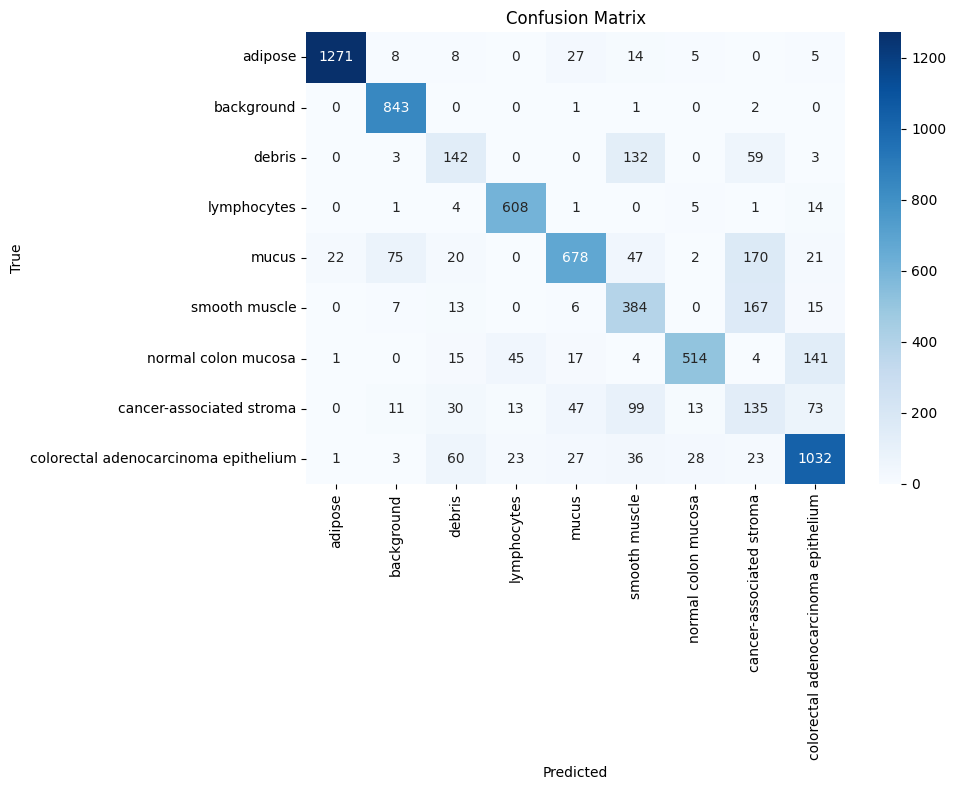

Accuracy: 0.7809
Macro Avg Precision: 0.7282
Macro Avg Recall: 0.7198
Macro Avg F1-Score: 0.7190


63044

In [ ]:
# Predict on test set (memory-efficient batching)
y_true = []
y_pred = []

print("Evaluating model on test set...")
for batch_num, (x, y) in enumerate(test_tf):
    preds = model.predict(x, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y.numpy(), axis=1))

    # Clear batch from memory
    del preds, x, y

    if batch_num % 50 == 0:
        print(f"Processed {batch_num * 16} samples...")

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../data/samples/confusion_matrix.png', dpi=150)
plt.show()

# Metrics summary
print(f"Accuracy: {report['accuracy']:.4f}")
print(f"Macro Avg Precision: {report['macro avg']['precision']:.4f}")
print(f"Macro Avg Recall: {report['macro avg']['recall']:.4f}")
print(f"Macro Avg F1-Score: {report['macro avg']['f1-score']:.4f}")

# Clean up
del y_true, y_pred, cm
import gc
gc.collect()

## 7. Training History Visualization

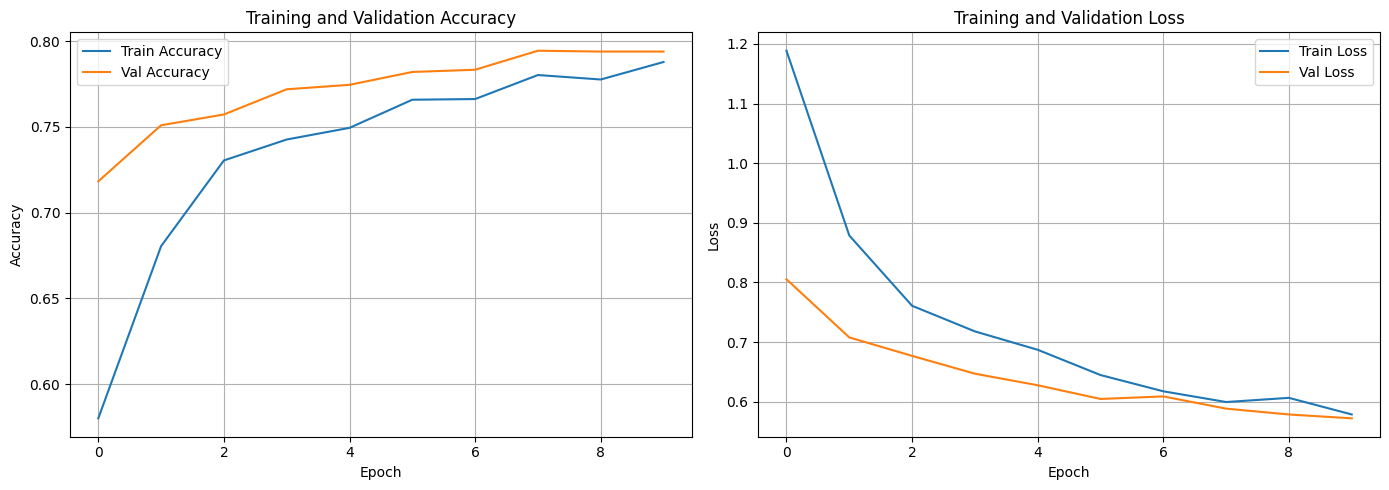

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../data/samples/training_history.png', dpi=150)
plt.show()

## 8. Save class labels for prediction

Save class names for use in the API prediction module.

In [ ]:
with open('../models/classes.txt', 'w') as f:
    f.write('\n'.join(class_names))
print('Class labels saved to models/classes.txt')

Class labels saved to models/classes.txt


## Summary

- **Dataset**: PathMNIST (9-class histology images, 89,996 train, 10,004 val, 7,180 test)
- **Preprocessing**: Resize 28x28 → 96x96, normalize to [0,1]
- **Model**: MobileNetV2 transfer learning with custom classifier
- **Optimization**: Early stopping, dropout, Adam optimizer
- **Metrics**: Accuracy, Precision, Recall, F1-score, Confusion Matrix
- **Model saved**: `models/model.h5`